# Topic: Analyzing the Dark Matter Halo Shape of M33 

### Question: Does M33's halo shape at the present day look prolate, oblate, triaxial, or none of the above

### Output Plot: Isodensity ellipses fitted on a 2D histogram of the halo particles 

### Code outline:

1. Create CenterOfMass object for M33 using halo particles to find the halo COM. (Lab 7)
2. Calculate COM frame positions of the halo particles, separated into x, y, and z coordinates. (Lab 7)
3. Construct 2D histogram of desired projection using matplotlib with reasonable binning. (Lab 7)
4. Retrieve the 2D array image produced by the 2D histogram and fit isodensity ellipses to the image using photutils
5. Plot fitted ellipses over original image and visually analyze shape 

In [1]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile

# for contours
import scipy.optimize as so 

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

# Code From Lab 7

In [2]:
# Create a COM of object for M33 Halo (particle type=1) Using Code from Homework 4

# Using HighRes version of M33_000.txt 
COMD = CenterOfMass("M33_000.txt",1)

In [3]:
# Compute COM of M33 using halo particles
COMP = COMD.COM_P(0.1)
COMV = COMD.COM_V(COMP[0],COMP[1],COMP[2])

In [4]:
# Determine positions of halo particles relative to COM 
xD = COMD.x - COMP[0].value 
yD = COMD.y - COMP[1].value 
zD = COMD.z - COMP[2].value 

# total magnitude
rtot = np.sqrt(xD**2 + yD**2 + zD**2)

# Determine velocities of halo particles relative to COM motion
vxD = COMD.vx - COMV[0].value 
vyD = COMD.vy - COMV[1].value 
vzD = COMD.vz - COMV[2].value 

# total velocity 
vtot = np.sqrt(vxD**2 + vyD**2 + vzD**2)

# Arrays for r and v 
r = np.array([xD,yD,zD]).T # transposed 
v = np.array([vxD,vyD,vzD]).T

# Create 2D density histogram 

Create plot of M33's halo density, using 2D Histograms 

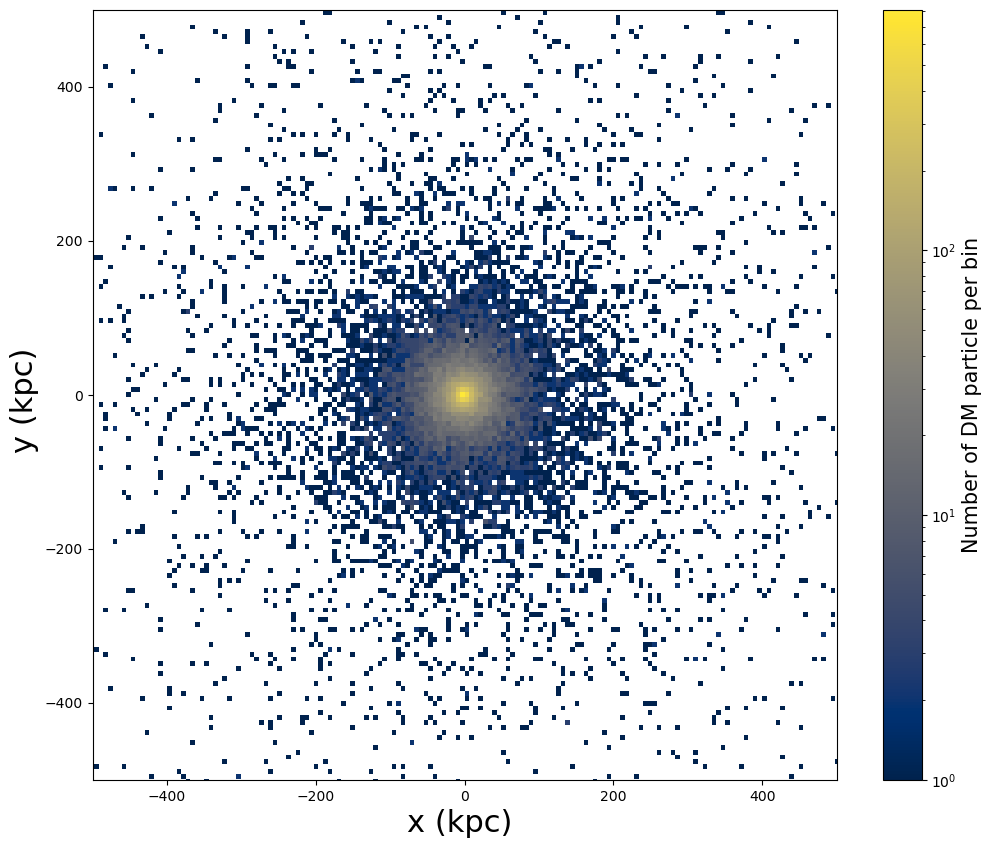

In [5]:
# 1) Make plots 

# M33 Disk Density 
fig, ax= plt.subplots(figsize=(12, 10))

# ADD HERE
# plot the particle density for M33 using a 2D historgram
# plt.hist2D(pos1,pos2, bins=, norm=LogNorm(), cmap='' )
# cmap options: 
# https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html  
#   e.g. 'magma', 'viridis'
# can modify bin number to make the plot smoother
h_xy = plt.hist2d(xD,yD, bins=1500, norm=LogNorm(), cmap='cividis')

cbar = plt.colorbar()
cbar.set_label("Number of DM particle per bin", fontsize=15)

# Add axis labels
plt.xlabel('x (kpc) ', fontsize=22)
plt.ylabel('y (kpc) ', fontsize=22)

#set axis limits
l = 0.5e3 # length of box to show in kpc
plt.ylim(-l,l)
plt.xlim(-l,l)

#adjust tick label font size
label_size = 10
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size


# Save to a file
#plt.savefig('Lab7_M31DMHalo.png', bbox_inches='tight')

In [14]:

def RotateFrame(posI,velI):
    """a function that will rotate the position and velocity vectors
    so that the disk angular momentum is aligned with z axis. 
    
    PARAMETERS
    ----------
        posI : `array of floats`
             3D array of positions (x,y,z)
        velI : `array of floats`
             3D array of velocities (vx,vy,vz)
             
    RETURNS
    -------
        pos: `array of floats`
            rotated 3D array of positions (x,y,z) 
            such that disk is in the XY plane
        vel: `array of floats`
            rotated 3D array of velocities (vx,vy,vz) 
            such that disk angular momentum vector
            is in the +z direction 
    """
    
    # compute the angular momentum
    L = np.sum(np.cross(posI,velI), axis=0)
    
    # normalize the angular momentum vector
    L_norm = L/np.sqrt(np.sum(L**2))


    # Set up rotation matrix to map L_norm to
    # z unit vector (disk in xy-plane)
    
    # z unit vector
    z_norm = np.array([0, 0, 1])
    
    # cross product between L and z
    vv = np.cross(L_norm, z_norm)
    s = np.sqrt(np.sum(vv**2))
    
    # dot product between L and z 
    c = np.dot(L_norm, z_norm)
    
    # rotation matrix
    I = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
    v_x = np.array([[0, -vv[2], vv[1]], [vv[2], 0, -vv[0]], [-vv[1], vv[0], 0]])
    R = I + v_x + np.dot(v_x, v_x)*(1 - c)/s**2

    # Rotate coordinate system
    pos = np.dot(R, posI.T).T
    vel = np.dot(R, velI.T).T
    
    return pos, vel


In [15]:
# ADD HERE
# compute the rotated position and velocity vectors
rn, vn = RotateFrame(r, v)

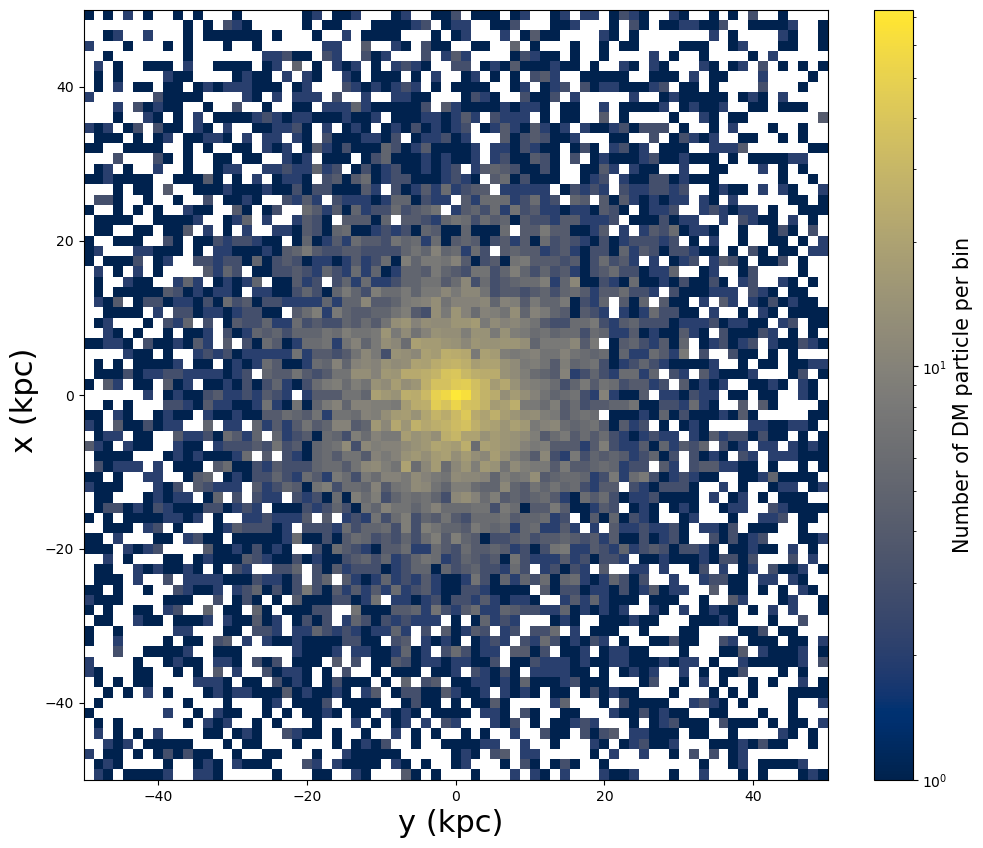

In [102]:
# 1) Make plots 

# M33 Disk Density 
fig, ax= plt.subplots(figsize=(12, 10))

# ADD HERE
# plot the particle density for M33 using a 2D historgram
# plt.hist2D(pos1,pos2, bins=, norm=LogNorm(), cmap='' )
# cmap options: 
# https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html  
#   e.g. 'magma', 'viridis'
# can modify bin number to make the plot smoother
h_xy = plt.hist2d(rn[:,0], rn[:,1], range = ((-50, 50), (-50, 50)), bins=75, norm=LogNorm(), cmap='cividis')

cbar = plt.colorbar()
cbar.set_label("Number of DM particle per bin", fontsize=15)

# Add axis labels
plt.xlabel('y (kpc) ', fontsize=22)
plt.ylabel('x (kpc) ', fontsize=22)

#set axis limits
# l = 0.5e3 # length of box to show in kpc
# plt.ylim(-l,l)
# plt.xlim(-l,l)

#adjust tick label font size
label_size = 10
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size


# Save to a file
#plt.savefig('Lab7_M31DMHalo.png', bbox_inches='tight')

In [197]:
x_binsize = (h_xy[2][1] - h_xy[2][0]) # same for all 3 projections
y_binsize = (h_xy[1][1] - h_xy[1][0])

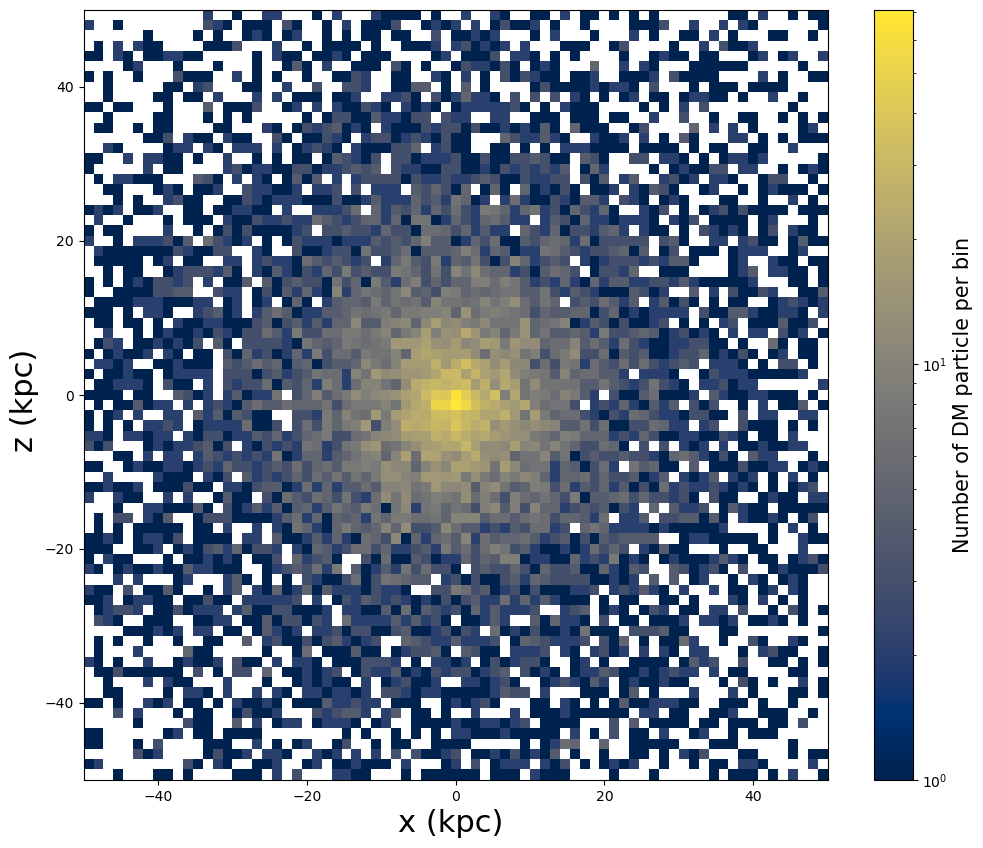

In [101]:
# M33 Disk Density 
fig, ax= plt.subplots(figsize=(12, 10))

# ADD HERE
# plot the particle density for M33 using a 2D historgram
# plt.hist2D(pos1,pos2, bins=, norm=LogNorm(), cmap='' )
# cmap options: 
# https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html  
#   e.g. 'magma', 'viridis'
# can modify bin number to make the plot smoother
h_xz = plt.hist2d(rn[:,0], rn[:,2], range = ((-50, 50), (-50, 50)), bins=75, norm=LogNorm(), cmap='cividis')

cbar = plt.colorbar()
cbar.set_label("Number of DM particle per bin", fontsize=15)

# Add axis labels
plt.xlabel('x (kpc) ', fontsize=22)
plt.ylabel('z (kpc) ', fontsize=22)

#set axis limits
# l = 0.5e3 # length of box to show in kpc
# plt.ylim(-l,l)
# plt.xlim(-l,l)

#adjust tick label font size
label_size = 10
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size



# Save to a file
#plt.savefig('Lab7_M31DMHalo.png', bbox_inches='tight')

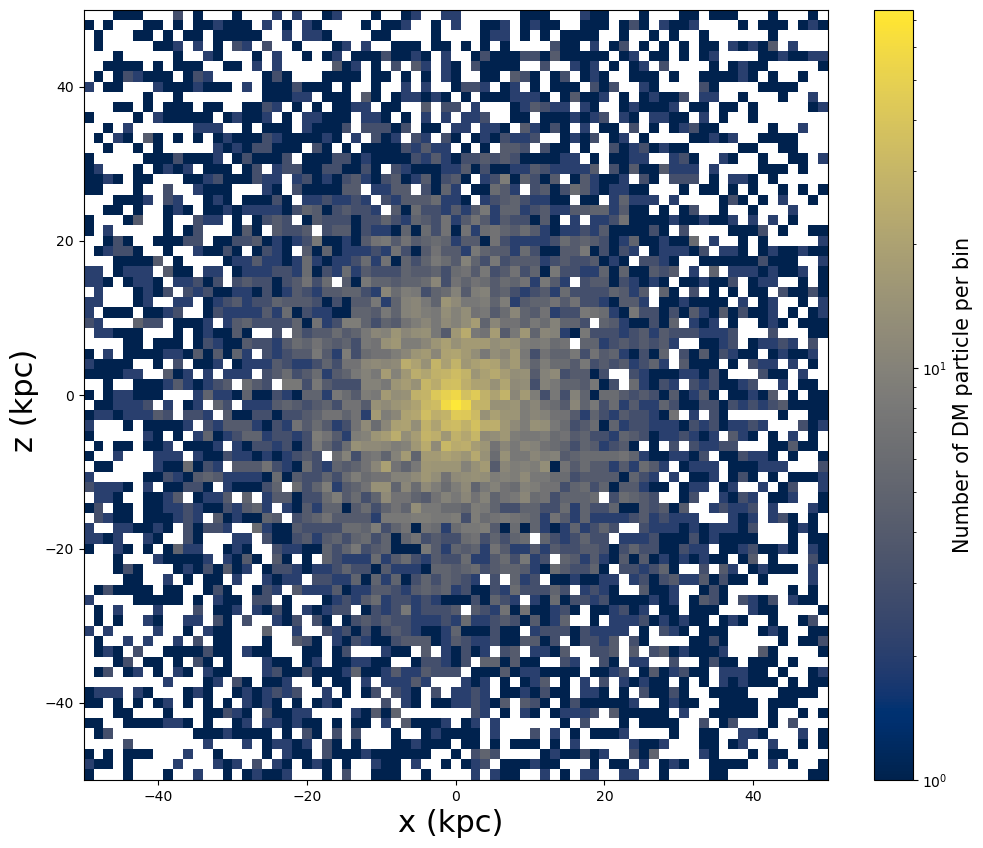

In [91]:
# M33 Disk Density 
fig, ax= plt.subplots(figsize=(12, 10))

# ADD HERE
# plot the particle density for M33 using a 2D historgram
# plt.hist2D(pos1,pos2, bins=, norm=LogNorm(), cmap='' )
# cmap options: 
# https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html  
#   e.g. 'magma', 'viridis'
# can modify bin number to make the plot smoother
h_yz = plt.hist2d(rn[:,1], rn[:,2], range = ((-50, 50), (-50, 50)), bins=75, norm=LogNorm(), cmap='cividis')

cbar = plt.colorbar()
cbar.set_label("Number of DM particle per bin", fontsize=15)

# Add axis labels
plt.xlabel('x (kpc) ', fontsize=22)
plt.ylabel('z (kpc) ', fontsize=22)

#set axis limits
# l = 250 # length of box to show in kpc
# plt.ylim(-l,l)
# plt.xlim(-l,l)

#adjust tick label font size
label_size = 10
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size



# Save to a file
#plt.savefig('Lab7_M31DMHalo.png', bbox_inches='tight')

In [195]:
def PlotEllipses(img_data, sma=10):
    """
    Function to plot fitted isodensity ellipses over 2D histogram projection of halo particle density 
    
    Inputs:
        - img_data (2D numpy array): Output 2D array from plt.hist2d 
        - sma (int, float): Initial guess of the semimajor axis length (in pixels) of the core region.
            Default value of 10 pixels.
        
    Outputs:
        Plots ellipses on top of projected image (axis labels not included)
    """
    
    # Need to log10 the density data so that photutils can create ellipses based on a log scale 
    # Will not work without taking the log of the density data 
    fits_data = np.log10(img_data, where=(img_data != 0) ) # ignore where bin density is 0
    
    # Find where the highest density bin is and treat that as the object center (in pixel coordinates)
    x0 = np.where(img_data == np.max(img_data))[1][0]
    y0 = np.where(img_data == np.max(img_data))[0][0]

    
    ny, nx = fits_data.shape # Image size 
    
    # Initial guess of the ellipse geometry of the core region (sma will vary based on binning)
    geometry = EllipseGeometry(x0=x0, y0=y0, sma=sma, eps=0.3, pa=0.0, )
    
    # Create photutils Ellipse object using the fits_data and ellipse geometry 
    ellipse = Ellipse(fits_data, geometry)
    
    # Use photutils method fit_image to fit ellipses to the data out to a maximum sma length of 50 pixels 
    isolist = ellipse.fit_image(maxsma=37.5)

    #Useful plot that displays sma versus ellipticity and position angle to quantify the shape 
    fig, ax = plt.subplots(ncols=2, figsize=(10,5))
    ax[0].errorbar(isolist.sma*y_binsize, isolist.eps, yerr=isolist.ellip_err, fmt='o', markersize=4)
    ax[0].set_xlabel('Semimajor axis length [kpc]')
    ax[0].set_ylabel('Ellipticity')
    ax[0].set_ylim(0,1)
    ax[0].axvline(25, c='magenta', linestyle=':', label="M33 Scale Radius")
    ax[0].axvline(25/2, c='magenta', linestyle='--', label="Half of Scale Radius")
    ax[0].legend()
    
    ax[1].errorbar(isolist.sma*y_binsize, isolist.pa, yerr=isolist.pa_err, fmt='o', markersize=4)
    ax[1].set_xlabel('Semimajor axis length [kpc]')
    ax[1].set_ylabel('Position Angle')
    ax[1].axvline(25, c='magenta', linestyle=':', label="M33 Scale Radius")
    ax[1].axvline(25/2, c='magenta', linestyle='--', label="Half of Scale Radius")
    ax[1].legend()
    
    #plt.errorbar(isolist.sma, isolist.pa, yerr=isolist.pa_err, fmt='o', markersize=4)
    
    plt.savefig('EllipseProfile.png', bbox_inches='tight')
    

    fig, ax = plt.subplots(figsize=(12, 10))
    sm = ax.imshow(img_data, norm=LogNorm(),  cmap='cividis', interpolation='none')
    w = nx * 0.05 # Show image box centered on the halo and is 10% the total image size in pixel length 
#     ax.set_xlim(x0 - w, x0 + w)
#     ax.set_ylim(y0 - w, y0 + w)
    
    # Plot the fitted ellipses 
    isos = []
    smas = np.arange(0, max(isolist.sma), 1)
    for sma in smas:
        iso = isolist.get_closest(sma)
        isos.append(iso)
        x, y, = iso.sampled_coordinates()
        plt.plot(x, y, color='lime', linewidth=0.5, linestyle='-')
        
    for sma in [25/y_binsize, 25/2/y_binsize]:
        iso = isolist.get_closest(sma)
        x, y, = iso.sampled_coordinates()
        plt.plot(x, y, color='magenta', linewidth=1, linestyle='-')

    cbar = plt.colorbar(sm)
    cbar.set_label("Number of DM particle per bin", fontsize=15)
    
    plt.savefig('ShapeAnalysis.png', bbox_inches='tight')
    return isolist

Text(116.97222222222221, 0.5, 'x (pixels) ')

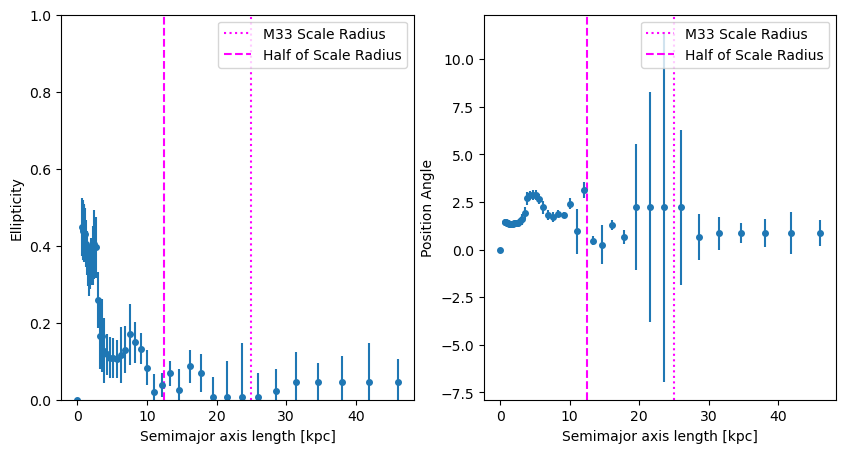

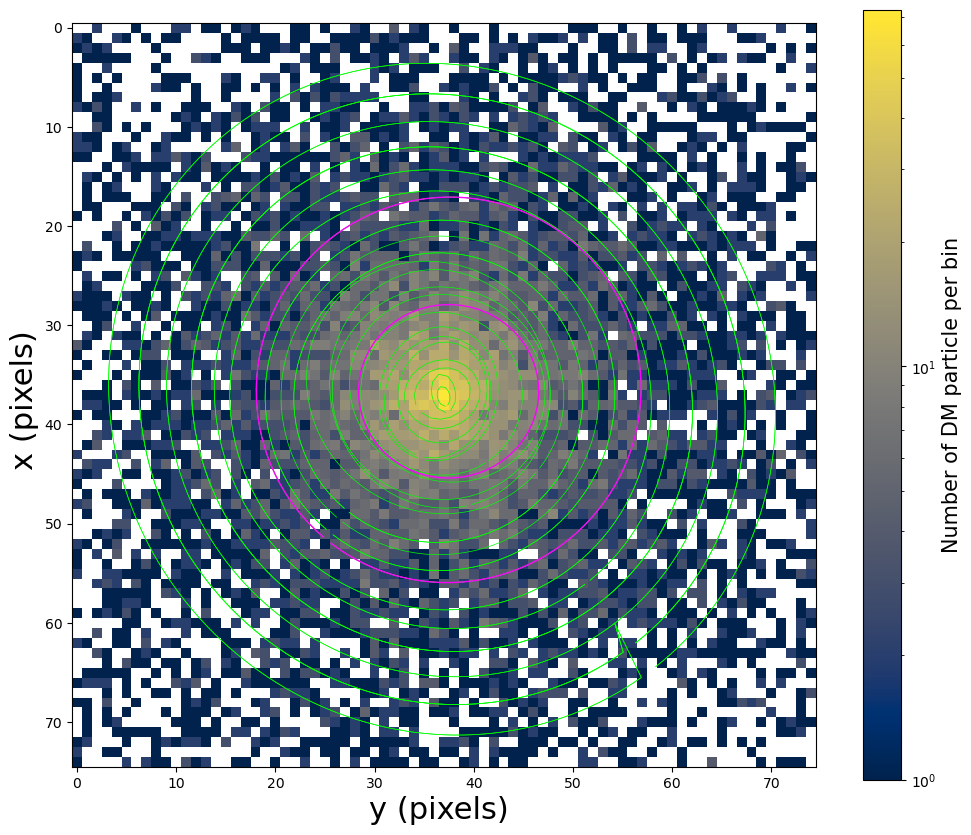

In [196]:
# Plot ellipses for x-y projection 
xy_isolist = PlotEllipses(h_xy[0])

# Add axis labels
plt.xlabel('y (pixels) ', fontsize=22)
plt.ylabel('x (pixels) ', fontsize=22)

Text(0, 0.5, 'x (pixels) ')

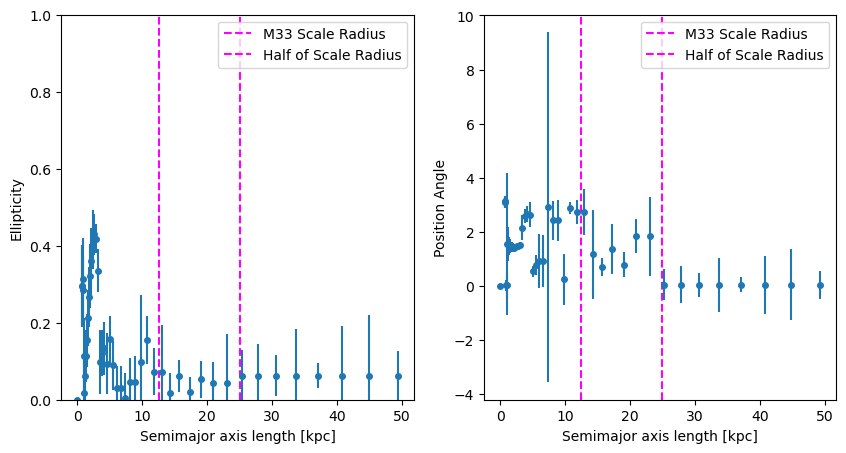

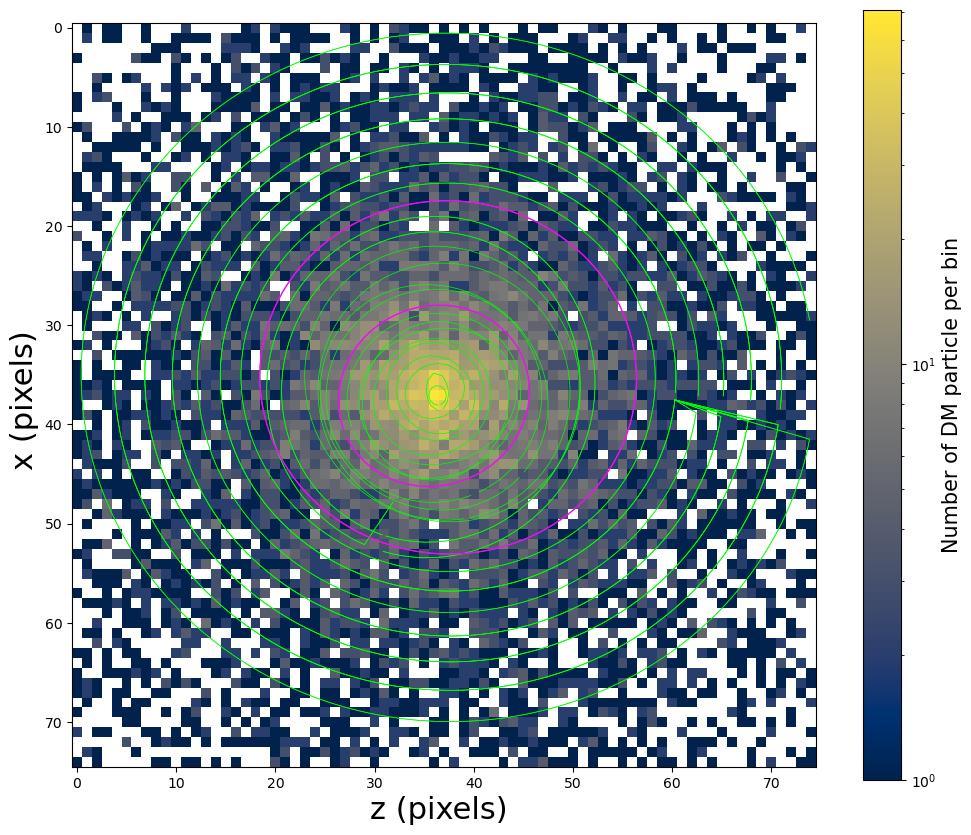

In [185]:
# Plot ellipses for x-z projection 
PlotEllipses(h_xz[0], sma=5)

# Add axis labels
plt.xlabel('z (pixels) ', fontsize=22)
plt.ylabel('x (pixels) ', fontsize=22)

Text(0, 0.5, 'y (pixels) ')

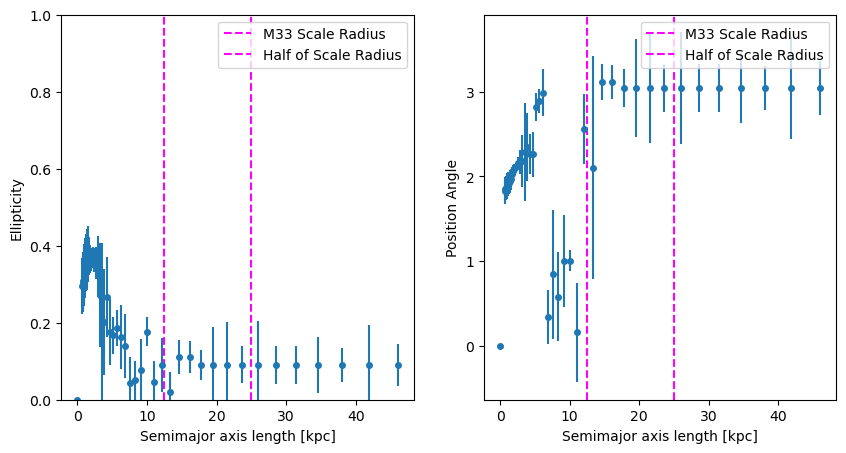

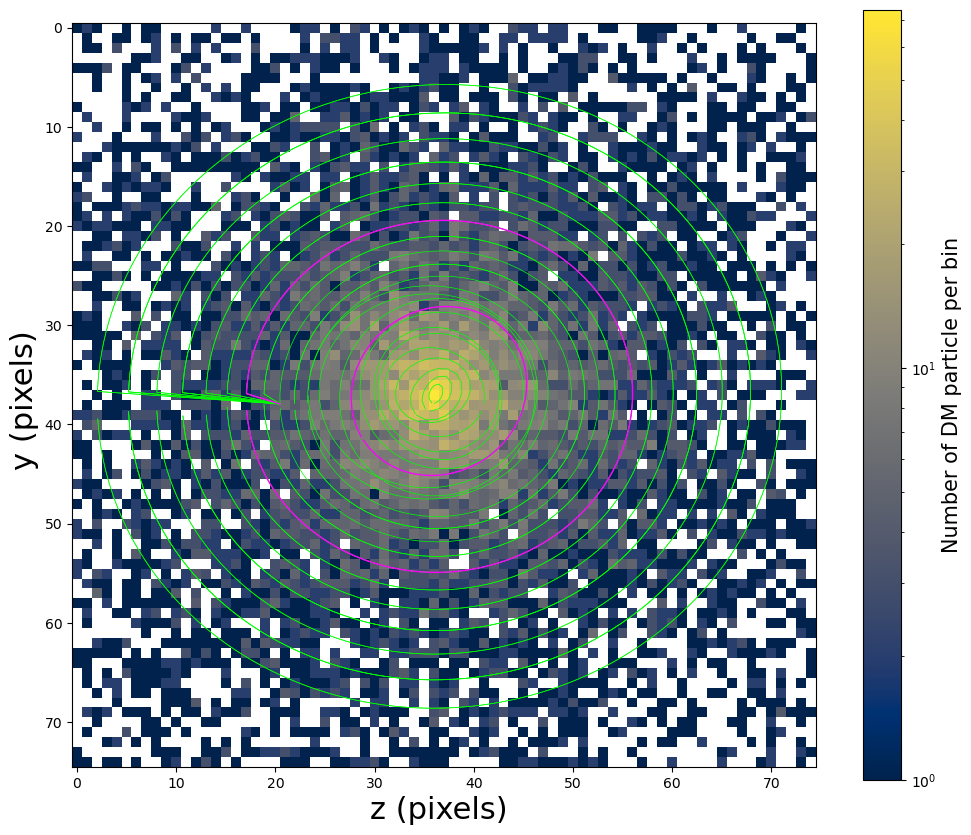

In [186]:
# Plot ellipses for y-z projection 
PlotEllipses(h_yz[0])

# Add axis labels
plt.xlabel('z (pixels) ', fontsize=22)
plt.ylabel('y (pixels) ', fontsize=22)

In [ ]:
# rotate perspective to be viewing relative to the disk 
# scale radius where does radius drop by a factor of 2
# scale radius is 25.0 kpc (from hw5)
# link ellipticity to shape 
# semimajor axis and semiminor axis do it for different projections to determine if triaxial 
# softening length ; start with factor of 2 of this, dont go smaller than this 

# softening length is 290 pc (from Besla et al. 2012)